In [1]:
from zipfile import ZipFile
from typing import List, Dict
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, learning_curve
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score,roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.calibration import calibration_curve
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

In [2]:
zip_path = "Downloads/FINAL_VDJdb_features.csv.zip"
label_col = "binding"
drop_cols = ["unnamed: 0", "vdjdb.score", "kmeans_cluster", "esmkmeans_cluster"]   
test_size = 0.20
top_k = 200
random_state = 42
c_val = 1.0
max_iter = 5000
class_weight = "balanced"

In [3]:
# logistic regression hyperparams
lr_preselect_n = 1000
lr_solver = "lbfgs"
lr_c_val = 0.5
lr_tol = 1e-3
lr_max_iter = 1000
lr_class_weight = "balanced"

# random forest hyperparams
rf_n_estimators = 300
rf_max_depth = None
rf_min_samples_split = 2
rf_min_samples_leaf = 1
rf_max_features= "sqrt"
rf_class_weight = "balanced"

# xgboost hyperparams
xgb_n_estimators= 400
xgb_max_depth = 6
xgb_learning_rate = 0.05
xgb_subsample = 0.8
xgb_colsample = 0.8
xgb_reg_lambda = 1.0
xgb_reg_alpha = 0.0
xgb_tree_method= "hist"
xgb_early_stopping   = 20

In [4]:
#Helper functions below

In [5]:
def find_csv_in_zip(zip_path: str) -> str:
    with ZipFile(zip_path) as zf:
        csvs = [n for n in zf.namelist() if n.lower().endswith(".csv")]
        if not csvs:
            raise FileNotFoundError(f"no csv found in {zip_path}")
        return csvs[0] if len(csvs) == 1 else sorted(csvs, key=len)[0]

In [6]:
def read_csv_from_zip(zip_path: str) -> pd.DataFrame:
    with ZipFile(zip_path) as zf:
        inner = find_csv_in_zip(zip_path)
        with zf.open(inner) as f:
            return pd.read_csv(f)

In [7]:
def numeric_feature_cols(df: pd.DataFrame, label: str, drop_cols: List[str]) -> List[str]:
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    drop_set = set(drop_cols)
    return [c for c in num_cols if c not in drop_set and c != label]

In [8]:
def eval_metrics(y_true, prob) -> Dict[str, float]:
    yhat = (prob >= 0.5).astype(int)
    return {
        "roc_auc": float(roc_auc_score(y_true, prob)),
        "f1": float(f1_score(y_true, yhat)),
        "accuracy": float(accuracy_score(y_true, yhat)),
        "precision": float(precision_score(y_true, yhat)),
        "recall": float(recall_score(y_true, yhat)),
    }

In [9]:
def report_metrics(name: str, metrics: Dict[str, float]):
    print(f"\n{name}")
    for k, v in metrics.items():
        print(f"  {k:<10} = {v:.4f}")

In [10]:
# load, lowercasing the columns, and prepping the features

df = read_csv_from_zip(zip_path)
df.columns = [c.lower() for c in df.columns]

if label_col not in df.columns:
    raise ValueError(f"label column '{label_col}' not found after lowercasing")

feature_cols = numeric_feature_cols(df, label_col, drop_cols)
print(f"loaded: {df.shape}, using {len(feature_cols)} numeric features (dropped {len(drop_cols)})")

x = df[feature_cols].copy()
y = df[label_col].astype(int).copy()

loaded: (18864, 3067), using 3046 numeric features (dropped 4)


In [11]:
# dedupe to avoid cross-split duplicates

dups = x.duplicated().sum()
if dups:
    x, y = x.loc[~x.duplicated()].reset_index(drop=True), y.loc[~x.duplicated()].reset_index(drop=True)
    print(f"removed {dups} duplicates; remaining rows: {len(x)}")

In [12]:
xtr, xte, ytr, yte = train_test_split(x, y, test_size=test_size, stratify=y, random_state=random_state)

print(f"train: {xtr.shape}, test: {xte.shape}, posrate(train)={ytr.mean():.3f}, posrate(test)={yte.mean():.3f}")

train: (15091, 3046), test: (3773, 3046), posrate(train)=0.500, posrate(test)=0.500


In [13]:
# LR with all features 

if lr_preselect_n and xtr.shape[1] > lr_preselect_n:
    skb = SelectKBest(f_classif, k=lr_preselect_n)
    xtr_fast = skb.fit_transform(xtr, ytr)
    xte_fast = skb.transform(xte)
    fast_cols = [feature_cols[i] for i in skb.get_support(indices=True)]
else:
    xtr_fast, xte_fast = xtr.values, xte.values
    fast_cols = feature_cols

xtr_fast, xte_fast = xtr_fast.astype("float32"), xte_fast.astype("float32")

pipe_lr_all = Pipeline([
    ("scale", StandardScaler(with_mean=True, with_std=True)),
    ("clf", LogisticRegression(
        penalty="l2",
        solver=lr_solver,
        C=lr_c_val,
        tol=lr_tol,
        max_iter=lr_max_iter,
        class_weight=lr_class_weight,
        random_state=random_state
    )),
])

pipe_lr_all.fit(xtr_fast, ytr)
prob_lr_all = pipe_lr_all.predict_proba(xte_fast)[:, 1]
metrics_lr_all = eval_metrics(yte, prob_lr_all)
report_metrics("logistic regression metrics", metrics_lr_all)


logistic regression metrics
  roc_auc    = 0.9163
  f1         = 0.8482
  accuracy   = 0.8373
  precision  = 0.7947
  recall     = 0.9093


In [14]:
# ranking by coef

lr_coefs = pipe_lr_all.named_steps["clf"].coef_.ravel()
lr_abs = np.abs(lr_coefs)
lr_idx = np.argsort(-lr_abs)
lr_top_features = [fast_cols[i] for i in lr_idx[:top_k]]

In [15]:
# retraining with top k

pipe_lr_topk = Pipeline([
    ("scale", StandardScaler(with_mean=True, with_std=True)),
    ("clf", LogisticRegression(
        penalty="l2",
        solver=lr_solver,
        C=lr_c_val,
        tol=lr_tol,
        max_iter=lr_max_iter,
        class_weight=lr_class_weight,
        random_state=random_state
    )),
])
pipe_lr_topk.fit(xtr[lr_top_features], ytr)
prob_lr_k = pipe_lr_topk.predict_proba(xte[lr_top_features])[:, 1]
metrics_lr_k = eval_metrics(yte, prob_lr_k)
report_metrics(f"logistic regression (top {top_k}, optimized)", metrics_lr_k)


logistic regression (top 200, optimized)
  roc_auc    = 0.9068
  f1         = 0.8421
  accuracy   = 0.8261
  precision  = 0.7712
  recall     = 0.9274


In [16]:
# Random Forest implementation

rf_all = RandomForestClassifier(
    n_estimators=rf_n_estimators,
    max_depth=rf_max_depth,
    min_samples_split=rf_min_samples_split,
    min_samples_leaf=rf_min_samples_leaf,
    max_features=rf_max_features,
    class_weight=rf_class_weight,
    n_jobs=-1,
    random_state=random_state,
)
rf_all.fit(xtr, ytr)
prob_rf_all = rf_all.predict_proba(xte)[:, 1]
metrics_rf_all = eval_metrics(yte, prob_rf_all)
report_metrics("random forest (all features, optimized)", metrics_rf_all)


random forest (all features, optimized)
  roc_auc    = 0.9324
  f1         = 0.8677
  accuracy   = 0.8574
  precision  = 0.8089
  recall     = 0.9358


In [17]:
rf_importances = rf_all.feature_importances_
rf_idx = np.argsort(-rf_importances)
rf_top_features = [feature_cols[i] for i in rf_idx[:top_k]]

rf_topk = RandomForestClassifier(
    n_estimators=max(150, rf_n_estimators // 2),  # half the trees for faster retrain
    max_depth=rf_max_depth,
    min_samples_split=rf_min_samples_split,
    min_samples_leaf=rf_min_samples_leaf,
    max_features=rf_max_features,
    class_weight=rf_class_weight,
    n_jobs=-1,
    random_state=random_state,
)


rf_topk.fit(xtr[rf_top_features], ytr)
prob_rf_k = rf_topk.predict_proba(xte[rf_top_features])[:, 1]
metrics_rf_k = eval_metrics(yte, prob_rf_k)
report_metrics(f"random forest (top {top_k}) metrics", metrics_rf_k)


random forest (top 200) metrics
  roc_auc    = 0.9590
  f1         = 0.8947
  accuracy   = 0.8903
  precision  = 0.8601
  recall     = 0.9321


In [18]:
pos = int(ytr.sum()); neg = len(ytr) - pos
scale_pos_weight = (neg / pos) if pos else 1.0

In [19]:
xgb_all = XGBClassifier(
        n_estimators=xgb_n_estimators,
        max_depth=xgb_max_depth,
        learning_rate=xgb_learning_rate,
        subsample=xgb_subsample,
        colsample_bytree=xgb_colsample,
        reg_lambda=xgb_reg_lambda,
        reg_alpha=xgb_reg_alpha,
        objective="binary:logistic",
        eval_metric="auc",
        tree_method=xgb_tree_method,
        importance_type="gain",
        n_jobs=-1,
        random_state=random_state,
        scale_pos_weight=scale_pos_weight,
    )

In [20]:
xgb_all.fit(xtr, ytr, eval_set=[(xte, yte)], verbose=False, early_stopping_rounds=xgb_early_stopping)

prob_xgb_all = xgb_all.predict_proba(xte)[:, 1]
metrics_xgb_all = eval_metrics(yte, prob_xgb_all)
report_metrics("xgboost metrics", metrics_xgb_all)

/opt/anaconda3/lib/python3.8/site-packages/xgboost/sklearn.py:793: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(



xgboost metrics
  roc_auc    = 0.9691
  f1         = 0.9084
  accuracy   = 0.9046
  precision  = 0.8733
  recall     = 0.9464


In [21]:
# rank and retrain
xgb_importances = xgb_all.feature_importances_
xgb_idx = np.argsort(-xgb_importances)
xgb_top_features = [feature_cols[i] for i in xgb_idx[:top_k]]

xgb_topk = XGBClassifier(
    n_estimators=max(150, xgb_n_estimators // 2),
    max_depth=xgb_max_depth,
    learning_rate=xgb_learning_rate,
    subsample=xgb_subsample,
    colsample_bytree=xgb_colsample,
    reg_lambda=xgb_reg_lambda,
    reg_alpha=xgb_reg_alpha,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method=xgb_tree_method,
    n_jobs=-1,
    random_state=random_state,
    scale_pos_weight=scale_pos_weight)

xgb_topk.fit(xtr[xgb_top_features], ytr)
prob_xgb_k = xgb_topk.predict_proba(xte[xgb_top_features])[:, 1]
metrics_xgb_k = eval_metrics(yte, prob_xgb_k)
report_metrics(f"xgboost (top {top_k}) metrics", metrics_xgb_k)


xgboost (top 200) metrics
  roc_auc    = 0.9717
  f1         = 0.9129
  accuracy   = 0.9102
  precision  = 0.8854
  recall     = 0.9422


In [22]:
#Visualizations Section

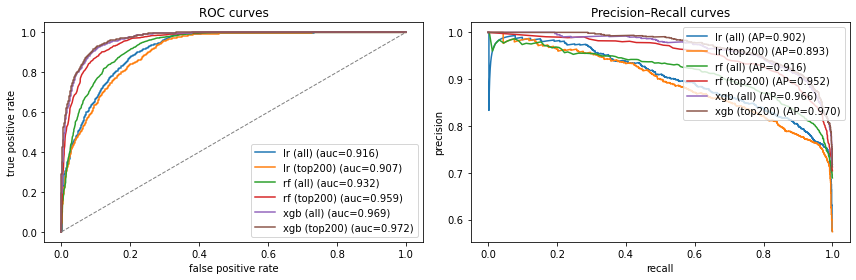

In [23]:
def plot_roc_pr(y_true, probs_dict):
    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    for name, p in probs_dict.items():
        fpr, tpr, _ = roc_curve(y_true, p)
        axes[0].plot(fpr, tpr, label=f"{name} (auc={auc(fpr,tpr):.3f})")
    axes[0].plot([0,1],[0,1],"--",lw=1,color="gray")
    axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate")
    axes[0].set_title("ROC curves"); axes[0].legend(loc="lower right")

    for name, p in probs_dict.items():
        pr, rc, _ = precision_recall_curve(y_true, p)
        ap = average_precision_score(y_true, p)
        axes[1].plot(rc, pr, label=f"{name} (AP={ap:.3f})")
    axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
    axes[1].set_title("Precision–Recall curves"); axes[1].legend(loc="upper right")

    plt.tight_layout(); plt.show()

probs_for_plots = {
    "lr (all)": prob_lr_all,
    f"lr (top{top_k})": prob_lr_k,
    "rf (all)": prob_rf_all,
    f"rf (top{top_k})": prob_rf_k,
}
if 'prob_xgb_all' in globals():
    probs_for_plots["xgb (all)"] = prob_xgb_all
if 'prob_xgb_k' in globals():
    probs_for_plots[f"xgb (top{top_k})"] = prob_xgb_k

plot_roc_pr(yte.values if hasattr(yte,'values') else yte, probs_for_plots)

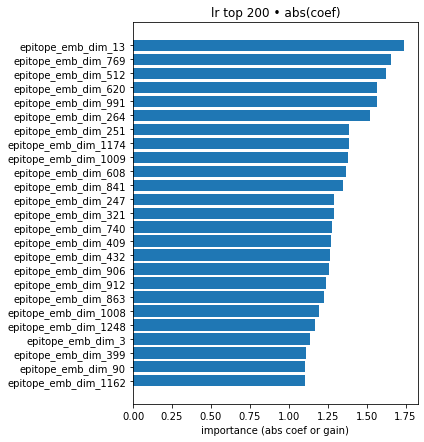

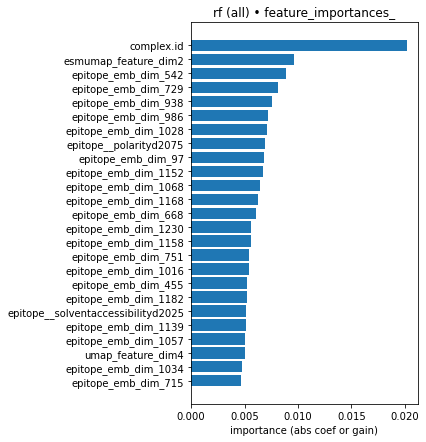

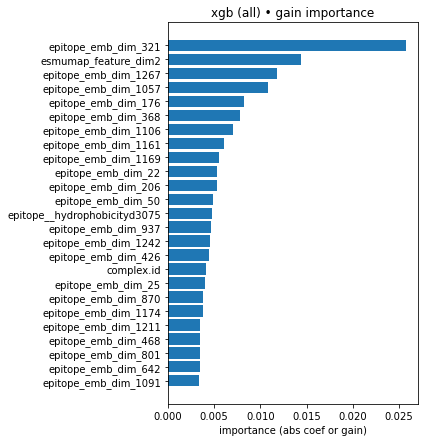

In [24]:
def bar_top_features(names, scores, title, k=25):
    order = np.argsort(-np.abs(scores))[:k]
    plt.figure(figsize=(6, max(3, k*0.25)))
    plt.barh(np.array(names)[order][::-1], np.array(scores)[order][::-1])
    plt.title(title); plt.xlabel("importance (abs coef or gain)"); plt.tight_layout(); plt.show()

lr_coef = pipe_lr_topk.named_steps['clf'].coef_.ravel()
bar_top_features(lr_top_features, np.abs(lr_coef), f"lr top {top_k} • abs(coef)")

bar_top_features(feature_cols, rf_all.feature_importances_, "rf (all) • feature_importances_")

if 'xgb_all' in globals():
    bar_top_features(feature_cols, xgb_all.feature_importances_, "xgb (all) • gain importance")

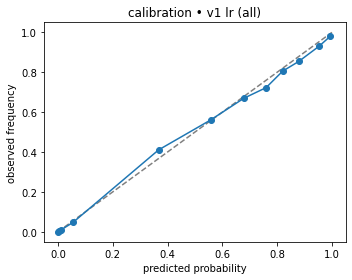

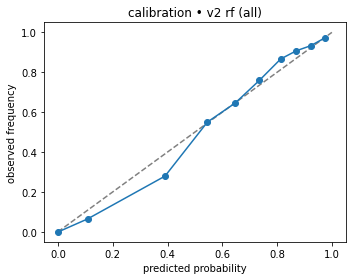

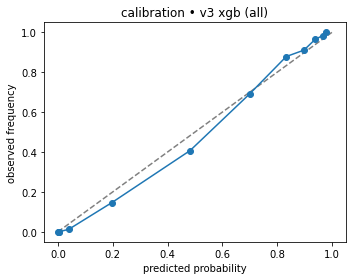

In [25]:
from sklearn.calibration import calibration_curve

def plot_calibration(y_true, probs, title):
    frac_pos, mean_pred = calibration_curve(y_true, probs, n_bins=12, strategy="quantile")
    plt.figure(figsize=(5,4))
    plt.plot([0,1],[0,1],"--",color="gray")
    plt.plot(mean_pred, frac_pos, marker="o")
    plt.xlabel("predicted probability"); plt.ylabel("observed frequency")
    plt.title(title); plt.tight_layout(); plt.show()

plot_calibration(yte, prob_lr_all, "calibration • v1 lr (all)")
plot_calibration(yte, prob_rf_all, "calibration • v2 rf (all)")
if 'prob_xgb_all' in globals():
    plot_calibration(yte, prob_xgb_all, "calibration • v3 xgb (all)")

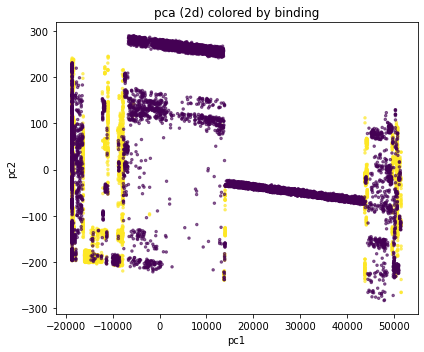

In [26]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=random_state)
xy = pca.fit_transform(x.values.astype("float32"))
plt.figure(figsize=(6,5))
plt.scatter(xy[:,0], xy[:,1], c=y.values, s=6, alpha=0.6)
plt.xlabel("pc1"); plt.ylabel("pc2"); plt.title("pca (2d) colored by binding")
plt.tight_layout(); plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import FunctionTransformer

def make_selector(cols):
    return FunctionTransformer(lambda df: df[cols].values, validate=False)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
scoring = {
    "roc_auc": "roc_auc",
    "f1": "f1",
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
}

cv_rows = []

# logistic (top-k)
pipe_lr_cv = Pipeline([
    ("select", make_selector(lr_top_features)),
    ("scale", StandardScaler(with_mean=True, with_std=True)),
    ("clf", LogisticRegression(
        penalty="l2", solver="lbfgs", C=0.5, tol=1e-3, max_iter=1000,
        class_weight="balanced", random_state=random_state
    )),
])
res_lr = cross_validate(pipe_lr_cv, x, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
cv_rows.append(("logistic (top{0})".format(top_k), res_lr))

# random forest (top-k)
pipe_rf_cv = Pipeline([
    ("select", make_selector(rf_top_features)),
    ("clf", RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_split=2, min_samples_leaf=1,
        max_features="sqrt", class_weight="balanced", n_jobs=-1, random_state=random_state
    )),
])
res_rf = cross_validate(pipe_rf_cv, x, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
cv_rows.append(("random forest (top{0})".format(top_k), res_rf))

# xgboost (top-k)
pos_all = int(y.sum()); neg_all = int(len(y) - pos_all)
spw = (neg_all / pos_all) if pos_all else 1.0
pipe_xgb_cv = Pipeline([
    ("select", make_selector(xgb_top_features)),
    ("clf", XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, reg_alpha=0.0, tree_method="hist",
        objective="binary:logistic", eval_metric="auc",
        n_jobs=-1, random_state=random_state, scale_pos_weight=spw
    )),
])
res_xgb = cross_validate(pipe_xgb_cv, x, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
cv_rows.append(("xgboost (top{0})".format(top_k), res_xgb))

# assemble summary table (mean ± std)
def mean_std(col):
    return f"{np.mean(col):.3f} ± {np.std(col):.3f}"

rows = []
for name, res in cv_rows:
    row = {
        "model": name,
        "roc_auc": mean_std(res["test_roc_auc"]),
        "f1": mean_std(res["test_f1"]),
        "accuracy": mean_std(res["test_accuracy"]),
        "precision": mean_std(res["test_precision"]),
        "recall": mean_std(res["test_recall"]),
    }
    rows.append(row)

cv_summary = pd.DataFrame(rows).set_index("model")
print("5-fold cross-validation (mean ± std)")
try:
    display(cv_summary)
except:
    print(cv_summary)

In [ ]:
# failure analysis
# choose best by auc on test set
auc_scores = {
    "xgb_topk": metrics_xgb_k["roc_auc"],
    "rf_topk": metrics_rf_k["roc_auc"],
    "lr_topk": metrics_lr_k["roc_auc"],
}
best_key = max(auc_scores, key=auc_scores.get)

if best_key == "xgb_topk":
    best_name = f"xgboost (top{top_k})"
    best_model = xgb_topk
    best_feats = xgb_top_features
elif best_key == "rf_topk":
    best_name = f"random forest (top{top_k})"
    best_model = rf_topk
    best_feats = rf_top_features
else:
    best_name = f"logistic (top{top_k})"
    best_model = pipe_lr_topk
    best_feats = lr_top_features

xte_best = xte[best_feats]
prob_best = best_model.predict_proba(xte_best)[:, 1]
yhat_best = (prob_best >= 0.5).astype(int)
mistakes = (yhat_best != yte.values)

test_index = xte.index.to_numpy()
mistake_index = test_index[mistakes]

fp_mask = (yte.values == 0) & (yhat_best == 1)
fn_mask = (yte.values == 1) & (yhat_best == 0)

fp_idx = np.where(fp_mask)[0]
ex_fp = fp_idx[np.argmax(prob_best[fp_idx])] if fp_idx.size > 0 else None

fn_idx = np.where(fn_mask)[0]
ex_fn = fn_idx[np.argmin(prob_best[fn_idx])] if fn_idx.size > 0 else None

if mistake_index.size > 0:
    mis_local_idx = np.where(mistakes)[0]
    ex_border = mis_local_idx[np.argmin(np.abs(prob_best[mis_local_idx] - 0.5))]
else:
    ex_border = None

chosen_local = [i for i in [ex_fp, ex_fn, ex_border] if i is not None]
chosen_global = [xte.index[i] for i in chosen_local]

nice_cols = [label_col, "vdjdb.score", "cdr3", "antigen.epitope", "gene", "species", "sequence"]
nice_cols = [c for c in nice_cols if c in df.columns]

k_show = min(8, len(best_feats))
cols_to_show = nice_cols + best_feats[:k_show]

fa_rows = df.loc[chosen_global, cols_to_show].copy()
fa_rows["pred_prob"] = prob_best[chosen_local]
fa_rows["pred_label"] = yhat_best[chosen_local]
fa_rows["true_label"] = yte.values[chosen_local]
fa_rows["error_type"] = ["FP" if yhat_best[i]==1 and yte.values[i]==0 else
                         "FN" if yhat_best[i]==0 and yte.values[i]==1 else
                         "misclass" for i in chosen_local]

print(f"failure analysis (best model: {best_name})")
print("three mistakes: highest-confidence FP, highest-confidence FN, and a borderline error")

display(fa_rows)